<a href="https://colab.research.google.com/github/23495A0516/Smart-Waste-Assessment-Collection-for-Holistic-Handling-SWACHH-/blob/main/Project_SWACHH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.listdir('/content/drive/MyDrive')

['Colab Notebooks', 'SWACHH_DATASET']

In [4]:
import zipfile

zip_path = "/content/drive/MyDrive/SWACHH_DATASET/dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully")

Dataset extracted successfully


In [5]:
import os
os.listdir("/content/dataset/dataset")

['Glass', 'Paper', 'Metal', 'Plastic', 'Textile']

In [8]:
import os
os.listdir("/content/dataset/dataset")

['Glass', 'Paper', 'Metal', 'Plastic', 'Textile']

In [9]:
DATASET_PATH = "/content/dataset/dataset"

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 3168 images belonging to 5 classes.
Found 791 images belonging to 5 classes.


In [11]:
classes = ["Glass","Metal","Paper","Plastic","Textile"]

In [12]:
import os
os.listdir("/content/dataset/dataset")

['Glass', 'Paper', 'Metal', 'Plastic', 'Textile']

In [13]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [14]:
IMG_SIZE = 224
BATCH_SIZE = 32
DATASET_PATH = "/content/dataset/dataset"

In [15]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 3168 images belonging to 5 classes.
Found 791 images belonging to 5 classes.


In [16]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [17]:
for layer in base_model.layers:
    layer.trainable = False

In [18]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

predictions = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [19]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 91s 714ms/step - accuracy: 0.3986 - loss: 1.4743 - val_accuracy: 0.6410 - val_loss: 0.9933
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 54s 544ms/step - accuracy: 0.7156 - loss: 0.7584 - val_accuracy: 0.7105 - val_loss: 0.7753
Epoch 3/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 53s 538ms/step - accuracy: 0.7915 - loss: 0.5671 - val_accuracy: 0.7370 - val_loss: 0.6862
Epoch 4/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 52s 527ms/step - accuracy: 0.8045 - loss: 0.5032 - val_accuracy: 0.7674 - val_loss: 0.6292
Epoch 5/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 54s 544ms/step - accuracy: 0.8560 - loss: 0.4223 - val_accuracy: 0.7800 - val_loss: 0.6200
Epoch 6/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 53s 538ms/step - accuracy: 0.8530 - loss: 0.4264 - val_accuracy: 0.7965 - val_loss: 0.5996
Epoch 7/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 53s 540ms/step - accuracy: 0.8639 - loss: 0.3717 - val_accuracy: 0.7788 - val_loss: 0.6023
Epoch 8/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 53s 540ms/step - accuracy: 0.8836 - loss: 0.3386 - val_accu

In [21]:
val_loss, val_acc = model.evaluate(val_data)
print("Validation Accuracy:", val_acc)

25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 460ms/step - accuracy: 0.8354 - loss: 0.5015
Validation Accuracy: 0.8141592741012573


In [22]:
for layer in base_model.layers[-20:]:
    layer.trainable = True

In [23]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
99/99 ━━━━━━━━━━━━━━━━━━━━ 77s 623ms/step - accuracy: 0.7021 - loss: 0.8090 - val_accuracy: 0.7939 - val_loss: 0.5781
Epoch 2/5
99/99 ━━━━━━━━━━━━━━━━━━━━ 54s 541ms/step - accuracy: 0.8290 - loss: 0.4623 - val_accuracy: 0.7788 - val_loss: 0.6409
Epoch 3/5
99/99 ━━━━━━━━━━━━━━━━━━━━ 53s 538ms/step - accuracy: 0.8661 - loss: 0.3823 - val_accuracy: 0.7826 - val_loss: 0.6292
Epoch 4/5
99/99 ━━━━━━━━━━━━━━━━━━━━ 63s 636ms/step - accuracy: 0.8921 - loss: 0.3361 - val_accuracy: 0.7788 - val_loss: 0.6405
Epoch 5/5
99/99 ━━━━━━━━━━━━━━━━━━━━ 54s 546ms/step - accuracy: 0.8932 - loss: 0.3120 - val_accuracy: 0.8104 - val_loss: 0.5820


In [25]:
val_loss, val_acc = model.evaluate(val_data)

print("Final Validation Accuracy:", val_acc)

25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 453ms/step - accuracy: 0.8026 - loss: 0.5917
Final Validation Accuracy: 0.7812895178794861


In [ ]:
model.save("waste_classifier.h5")

In [ ]:
from google.colab import files
files.download("waste_classifier.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
train_data.class_indices

{'Glass': 0, 'Metal': 1, 'Paper': 2, 'Plastic': 3, 'Textile': 4}

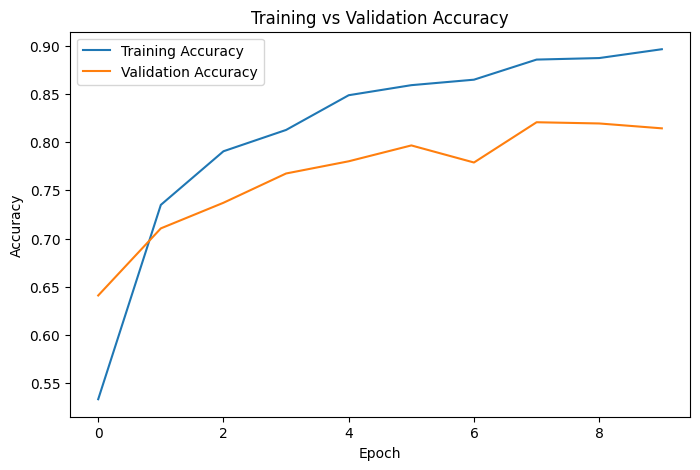

In [27]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.figure(figsize=(8,5))
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

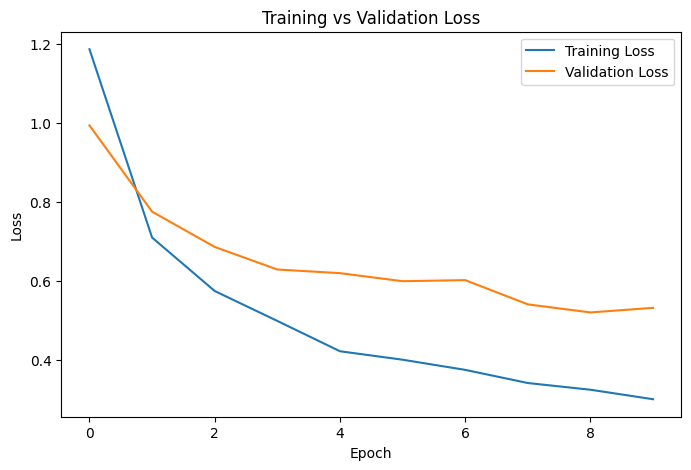

In [28]:
plt.figure(figsize=(8,5))
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 609ms/step


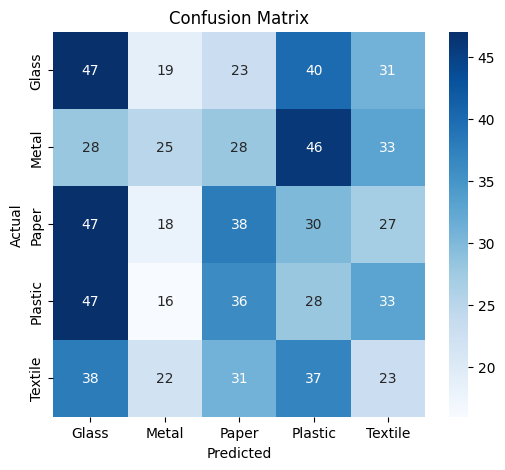

In [29]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

Y_pred = model.predict(val_data)
y_pred = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(val_data.classes, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_data.class_indices.keys(),
            yticklabels=train_data.class_indices.keys())

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [30]:
from sklearn.metrics import classification_report

print(classification_report(val_data.classes, y_pred,
      target_names=train_data.class_indices.keys()))

              precision    recall  f1-score   support

       Glass       0.23      0.29      0.26       160
       Metal       0.25      0.16      0.19       160
       Paper       0.24      0.24      0.24       160
     Plastic       0.15      0.17      0.16       160
     Textile       0.16      0.15      0.15       151

    accuracy                           0.20       791
   macro avg       0.21      0.20      0.20       791
weighted avg       0.21      0.20      0.20       791



1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step


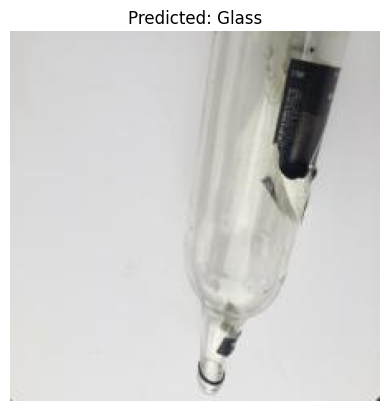

In [31]:
import random
from tensorflow.keras.preprocessing import image

class_names = list(train_data.class_indices.keys())

sample_path = val_data.filepaths[random.randint(0,len(val_data.filepaths)-1)]

img = image.load_img(sample_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]

plt.imshow(img)
plt.title("Predicted: " + predicted_class)
plt.axis('off')
plt.show()

In [32]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 5,657,809 (21.58 MB)

 Trainable params: 1,535,301 (5.86 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

 Optimizer params: 3,070,604 (11.71 MB)

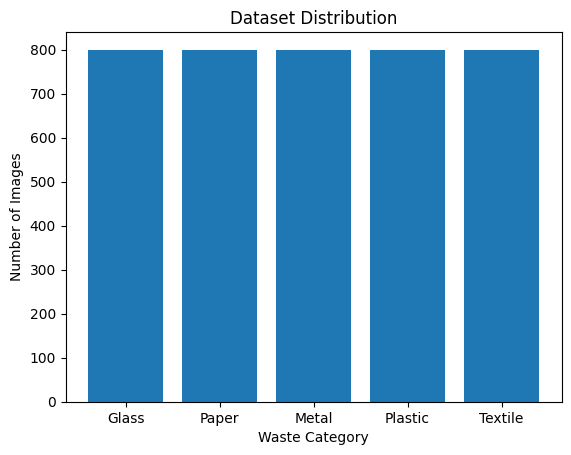

In [34]:
import os

dataset_path = "/content/dataset/dataset"

classes = os.listdir(dataset_path)
counts = []

for c in classes:
    counts.append(len(os.listdir(os.path.join(dataset_path,c))))

plt.bar(classes, counts)
plt.title("Dataset Distribution")
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.show()